Project Setup Block 

In [1]:
print('Bismillah')

Bismillah


In [2]:
# ==========================================
# 1. PROJECT SETUP & CONFIGURATION
# ==========================================

# Standard library imports
import warnings
import gc # Garbage collector for memory management

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# Environment Configuration
# ------------------------------------------
# Suppress warnings to keep the notebook clean for GitHub and stakeholders
warnings.filterwarnings('ignore')

# ------------------------------------------
# Pandas Display Options
# ------------------------------------------
# Ensure we can see all columns and a reasonable number of rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Format floats to 3 decimal places to avoid scientific notation (crucial for financial data)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# ------------------------------------------
# Visualization Defaults
# ------------------------------------------
# Set a clean, modern, and professional aesthetic for client presentations
sns.set_theme(style="whitegrid", palette="muted")

# Update matplotlib global parameters
plt.rcParams.update({
    'figure.figsize': (12, 6),      # Default wide aspect ratio suitable for time-series
    'axes.titlesize': 16,           # Clear, readable title sizes
    'axes.titleweight': 'bold',
    'axes.labelsize': 14,           # Axis label sizes
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 100,              # High resolution for GitHub rendering
    'axes.spines.top': False,       # Remove top/right borders for a cleaner look
    'axes.spines.right': False
})

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Professional Data Science Environment Setup Complete.")

✅ Professional Data Science Environment Setup Complete.


BLOCK 2

In [3]:
# ==========================================
# 2. DATA LOADING & MEMORY OPTIMIZATION (FINAL)
# ==========================================

import os
import time
import pandas as pd
import gc

# Define file paths using relative directories
RAW_DATA_PATH = os.path.join('..', 'data', 'raw', 'online_retail_II.xlsx')
PROCESSED_DATA_PATH = os.path.join('..', 'data', 'processed', 'online_retail.parquet')

def load_data():
    """
    Loads data from Parquet if available (fast), otherwise loads from Excel (slow),
    defensively fixes all mixed data types, and saves a Parquet checkpoint.
    """
    if os.path.exists(PROCESSED_DATA_PATH):
        print("✅ Found optimized Parquet file. Loading...")
        start_time = time.time()
        df = pd.read_parquet(PROCESSED_DATA_PATH)
        print(f"⏱️ Loaded in {time.time() - start_time:.2f} seconds.")
    else:
        print("⚠️ Optimized Parquet not found. Loading from raw Excel (this may take a few minutes)...")
        start_time = time.time()
        
        # Load both sheets
        df_sheet1 = pd.read_excel(RAW_DATA_PATH, sheet_name='Year 2009-2010')
        df_sheet2 = pd.read_excel(RAW_DATA_PATH, sheet_name='Year 2010-2011')
        
        # Concatenate the two years of data vertically
        df = pd.concat([df_sheet1, df_sheet2], ignore_index=True)
        print(f"⏱️ Loaded from Excel in {time.time() - start_time:.2f} seconds.")
        
        print("🔧 Defensively casting all text/ID columns to strings to prevent Parquet crashes...")
        # Force all non-math columns to strings. 
        # (Note: Customer ID has NaNs, which will temporarily become the string "nan". We will clean this in Phase 3).
        text_columns = ['Invoice', 'StockCode', 'Description', 'Customer ID', 'Country']
        for col in text_columns:
            df[col] = df[col].astype(str)
        
        print("💾 Saving optimized Parquet checkpoint for future runs...")
        df.to_parquet(PROCESSED_DATA_PATH, index=False)
        
        # Free up memory
        del df_sheet1, df_sheet2
        gc.collect() 
        
    return df

# Execute the loading function
df_raw = load_data()

# Inspect the true memory footprint
print("\n--- Dataset Memory Profile ---")
df_raw.info(memory_usage='deep')

✅ Found optimized Parquet file. Loading...
⏱️ Loaded in 1.65 seconds.

--- Dataset Memory Profile ---
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  str           
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   str           
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 122.9 MB


phase 3


In [4]:
# ==========================================
# 3. INITIAL INSPECTION
# ==========================================

print("--- First 5 Rows ---")
display(df_raw.head())

print("\n--- Last 5 Rows ---")
display(df_raw.tail())

print("\n--- Numerical Summary ---")
# We only describe numeric columns here. We round to 3 decimal places for readability.
display(df_raw.describe().T.round(3))

print("\n--- Date Range ---")
print(f"First Transaction: {df_raw['InvoiceDate'].min()}")
print(f"Last Transaction:  {df_raw['InvoiceDate'].max()}")

--- First 5 Rows ---


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,13085.0,United Kingdom



--- Last 5 Rows ---


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.100,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.150,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.150,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.950,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.000,12680.0,France



--- Numerical Summary ---


,count,mean,min,25%,50%,75%,max,std
Quantity,1067371.000,9.939,-80995.000,1.000,3.000,10.000,80995.000,172.706
InvoiceDate,1067371,2011-01-02 21:13:55.394029,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.000,4.649,-53594.360,1.250,2.100,4.150,38970.000,123.553



--- Date Range ---
First Transaction: 2009-12-01 07:45:00
Last Transaction:  2011-12-09 12:50:00


In [5]:
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'], errors='coerce')  # Ensure datetime format

In [6]:
df_raw.describe()

,Quantity,InvoiceDate,Price
count,1067371.000,1067371,1067371.000
mean,9.939,2011-01-02 21:13:55.394029,4.649
min,-80995.000,2009-12-01 07:45:00,-53594.360
25%,1.000,2010-07-09 09:46:00,1.250
50%,3.000,2010-12-07 15:28:00,2.100
75%,10.000,2011-07-22 10:23:00,4.150
max,80995.000,2011-12-09 12:50:00,38970.000
std,172.706,NaN,123.553


Phase 4


In [7]:
# ==========================================
# 4. DATA QUALITY ASSESSMENT
# ==========================================

print("--- 1. Missing Values Count ---")
missing_data = df_raw.isnull().sum()
display(missing_data[missing_data > 0].to_frame(name='Missing Rows'))

print("\n--- 2. Duplicate Records ---")
duplicate_count = df_raw.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df_raw)) * 100
print(f"Total Duplicate Rows: {duplicate_count:,} ({duplicate_percentage:.2f}%)")

print("\n--- 3. Structural Anomalies ---")
# Count how many rows have negative quantities
negative_qty_count = (df_raw['Quantity'] < 0).sum()
print(f"Rows with Negative Quantity (Likely Returns): {negative_qty_count:,}")

# Count how many rows have zero or negative prices
invalid_price_count = (df_raw['Price'] <= 0).sum()
print(f"Rows with Price <= 0 (Free items or Adjustments): {invalid_price_count:,}")

print("\n--- 4. Inspecting the 'C' (Cancelled) Invoices ---")
# Filter for invoices that start with 'C'
cancelled_invoices = df_raw[df_raw['Invoice'].str.startswith('C', na=False)]
print(f"Total Cancelled Invoices: {len(cancelled_invoices):,}")

# Let's look at the top 3 cancelled transactions to understand their structure
display(cancelled_invoices.head(3))

--- 1. Missing Values Count ---


,Missing Rows
Description,4382
Customer ID,243007



--- 2. Duplicate Records ---
Total Duplicate Rows: 34,335 (3.22%)

--- 3. Structural Anomalies ---
Rows with Negative Quantity (Likely Returns): 22,950
Rows with Price <= 0 (Free items or Adjustments): 6,207

--- 4. Inspecting the 'C' (Cancelled) Invoices ---
Total Cancelled Invoices: 19,494


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.950,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.650,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.250,16321.0,Australia


In [8]:
# ==========================================================
# DATA QUALITY ANALYZER
# ==========================================================

from IPython.display import display
import pandas as pd


class DataQualityAnalyzer:
    """
    Performs a comprehensive data quality assessment
    for a pandas DataFrame.
    """

    def __init__(self, dataframe):

        self.df = dataframe.copy()

        self.total_rows = len(self.df)
        self.total_columns = self.df.shape[1]

    # ------------------------------------------------------

    def dataset_overview(self):

        overview = pd.DataFrame({

            "Metric": [

                "Rows",
                "Columns",
                "Memory (MB)"

            ],

            "Value": [

                f"{self.total_rows:,}",
                self.total_columns,
                round(
                    self.df.memory_usage(deep=True).sum() / 1024**2,
                    2
                )

            ]

        })

        return overview

    # ------------------------------------------------------

    def missing_values(self):

        report = (

            self.df
            .isna()
            .sum()
            .rename("Missing Count")
            .to_frame()

        )

        report["Missing %"] = (

            report["Missing Count"]

            / self.total_rows

            * 100

        ).round(2)

        report = (

            report

            .query("`Missing Count` > 0")

            .sort_values(

                by="Missing Count",

                ascending=False

            )

        )

        return report

    # ------------------------------------------------------

    def duplicates(self):

        duplicate_count = self.df.duplicated().sum()

        return pd.DataFrame({

            "Metric": [

                "Duplicate Rows",

                "Duplicate Percentage"

            ],

            "Value": [

                duplicate_count,

                round(

                    duplicate_count

                    / self.total_rows

                    * 100,

                    2

                )

            ]

        })

    # ------------------------------------------------------

    def invalid_transactions(self):

        report = {

            "Negative Quantity":

                (self.df["Quantity"] < 0).sum(),

            "Price <= 0":

                (self.df["Price"] <= 0).sum(),

            "Cancelled Invoices":

                self.df["Invoice"]
                .astype(str)
                .str.startswith("C")
                .sum()

        }

        return (

            pd.DataFrame(

                report.items(),

                columns=[

                    "Issue",

                    "Count"

                ]

            )

        )

    # ------------------------------------------------------

    def data_types(self):

        report = pd.DataFrame({

            "Data Type":

                self.df.dtypes,

            "Non Null":

                self.df.count(),

            "Unique":

                self.df.nunique()

        })

        return report

    # ------------------------------------------------------

    def executive_summary(self):

        summary = {

            "Rows":
                self.total_rows,

            "Columns":
                self.total_columns,

            "Missing Values":
                self.df.isna().sum().sum(),

            "Duplicate Rows":
                self.df.duplicated().sum(),

            "Negative Quantity":
                (self.df["Quantity"] < 0).sum(),

            "Invalid Prices":
                (self.df["Price"] <= 0).sum(),

            "Cancelled Invoices":

                self.df["Invoice"]

                .astype(str)

                .str.startswith("C")

                .sum()

        }

        return pd.DataFrame(

            summary.items(),

            columns=[

                "Metric",

                "Value"

            ]

        )

    # ------------------------------------------------------

    def full_report(self):

        print("=" * 80)
        print("DATA QUALITY REPORT")
        print("=" * 80)

        print("\nDATASET OVERVIEW")
        display(self.dataset_overview())

        print("\nMISSING VALUES")
        display(self.missing_values())

        print("\nDUPLICATE RECORDS")
        display(self.duplicates())

        print("\nDATA TYPES")
        display(self.data_types())

        print("\nSTRUCTURAL ANOMALIES")
        display(self.invalid_transactions())

        print("\nEXECUTIVE SUMMARY")
        display(self.executive_summary())

        print("\nReport Generated Successfully.")

In [9]:
quality_report = DataQualityAnalyzer(df_raw)

quality_report.full_report()

DATA QUALITY REPORT

DATASET OVERVIEW


,Metric,Value
0,Rows,"1,067,371"
1,Columns,8
2,Memory (MB),122.930



MISSING VALUES


,Missing Count,Missing %
Customer ID,243007,22.770
Description,4382,0.410



DUPLICATE RECORDS


...


STRUCTURAL ANOMALIES


,Issue,Count
0,Negative Quantity,22950
1,Price <= 0,6207
2,Cancelled Invoices,19494



EXECUTIVE SUMMARY


,Metric,Value
0,Rows,1067371
1,Columns,8
2,Missing Values,247389
3,Duplicate Rows,34335
4,Negative Quantity,22950
5,Invalid Prices,6207
6,Cancelled Invoices,19494



Report Generated Successfully.


This is brilliant work. You have just pulled back the curtain on the actual state of this company’s database.

Let’s put our Senior Data Scientist hats on and look at these numbers. Do you see the hidden trap?

### **The Data Scientist's Eye (Interpreting Your Output)**

1. **The Cancellation Discrepancy:** Look at the negative quantities (**22,950**) versus the invoices starting with 'C' (**19,494**). There are almost **3,500 transactions** that have a negative quantity but *do not* have a 'C' in the invoice number.
* *Business Insight:* These aren't customer returns! These are likely inventory write-offs (e.g., "damaged in warehouse", "lost in transit", or "system adjustment"). If we just filtered by 'C', we would leave 3,500 corrupted rows in our training data.


2. **The Duplicates (3.22%):** 34,335 rows are exact duplicates.
* *Business Insight:* In retail, if a customer buys two coffee mugs, the cashier might scan the barcode twice instead of changing the quantity to "2". This creates two identical rows in the database. If we blindly run `df.drop_duplicates()`, we are actively deleting real revenue from the company's ledger! We must be very careful.


3. **The Refunds:** The sample of 'C' invoices shows a negative quantity, but a *positive* price.
* *Business Insight:* To calculate the revenue impact of a return, the formula will be `Quantity * Price` (e.g., -12 * £2.95 = -£35.40). The accounting perfectly balances itself out.



We have successfully audited the data quality. We will handle the actual *cleaning* of these anomalies in Phase 3.

Right now, we need to continue Phase 2 and answer the core business questions about what this company actually sells and to whom. Let's move to **Sections 9 & 10: Univariate & Bivariate Analysis**.

---

## 1. Objective

To visualize the core business drivers by analyzing the distribution of sales across different countries and identifying the most popular products.

## 2. Business Question

Who are our biggest international markets, and what products are driving the highest volume of sales?

## 3. Industry Perspective

In raw transactional data, the "whales" (massive outliers or extreme top-performers) heavily skew visualizations. Furthermore, if we plot revenue right now, the massive -£50,000 accounting adjustments will ruin the scale of our charts. A professional approach is to create a temporary "clean" view purely for EDA visualizations, without altering the raw data.

## 4. Best Practices

* **Temporary Filtering:** Create a temporary DataFrame (`df_eda`) that filters out negative prices and quantities so our charts represent *actual successful sales*.
* **Relative Sizing:** When plotting countries, always isolate the domestic market (the UK) from the international market. The UK will account for ~90% of sales, making the other countries invisible on a chart if plotted together.

## 5. Common Beginner Mistakes

* Plotting a bar chart of all 4,000+ products (which results in an unreadable black block of ink). We only plot the Top 10 or Top 20.
* Forgetting to use `.copy()` when making a temporary DataFrame, triggering Pandas' dreaded `SettingWithCopyWarning`.

## 

## 7. Code Walkthrough

* `df_raw[(df_raw['Quantity'] > 0) & (df_raw['Price'] > 0)]`: We are temporarily ignoring the returns, cancellations, and free items just so our charts show positive sales momentum.
* `plt.subplots(1, 2)`: We create a 1x2 grid to show two charts side-by-side, saving vertical space in the notebook.
* `value_counts()` vs `groupby().sum()`: For countries, we count the *number of rows* (transactions). For products, we want the *total items sold*, so we group by the product and sum the `Quantity` column.

## 8. Output Interpretation

*(I will wait for you to run this and look at the charts before we finalize the interpretation!)*

## 9. Business Insight

Visualizing top drivers allows the supply chain team to know exactly which items to keep overstocked in the warehouse (the top 10 products), and allows the marketing team to know which countries to target with localized ad campaigns.

## 10. Recommendation

Always format your charts so the labels are readable. By putting the Categories (Countries/Products) on the Y-axis and the values on the X-axis (a horizontal bar chart), we prevent the long product names from overlapping and becoming unreadable.

## 11. Interview Discussion

**Interviewer:** *"If a dataset is heavily skewed by a domestic market that accounts for 90% of the data, how do you visualize the remaining 10% effectively?"*
**Your Answer:** *"If I plot them together, the domestic market will compress the variance of the international markets to the point of being unreadable. I handle this either by applying a logarithmic scale to the axis, or, more effectively for business stakeholders, by creating two separate visualizations: one highlighting domestic dominance, and another filtering out the domestic market entirely to analyze international distribution independently."*

## 12. Summary

We have created a safe EDA view of our data and are now visualizing the geographic and product-level drivers of the company's sales.

---

Please run the visualization code. What are the top two international countries, and what is the #1 best-selling product? Let me know, and we will move to **Section 12: Time-Series Exploration**.

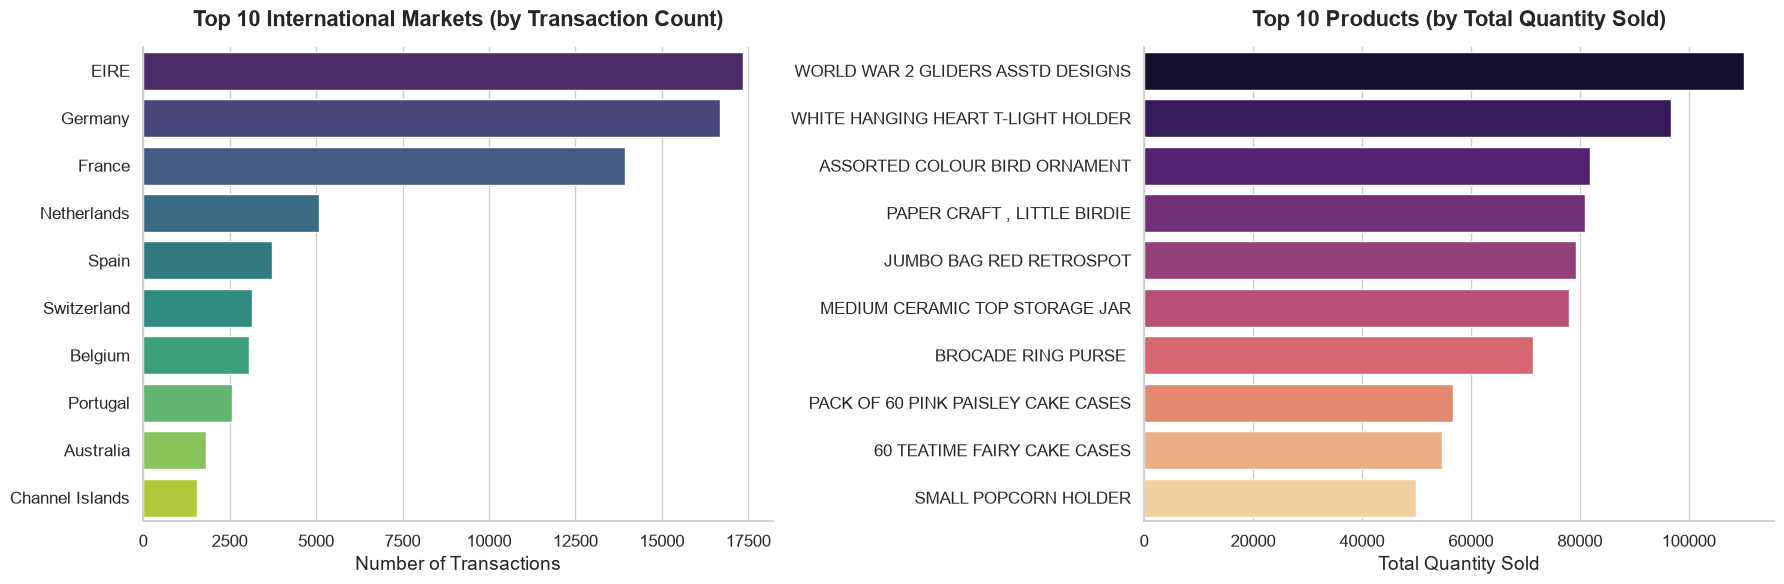

In [10]:
# ==========================================
# 9 & 10. UNIVARIATE & BIVARIATE ANALYSIS
# ==========================================

# Create a temporary dataframe for visual EDA (Excluding returns and errors)
df_eda = df_raw[(df_raw['Quantity'] > 0) & (df_raw['Price'] > 0)].copy()

# Set up the matplotlib figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ------------------------------------------
# Chart 1: Top 10 International Markets
# ------------------------------------------
# Exclude the UK to see the international footprint
df_intl = df_eda[df_eda['Country'] != 'United Kingdom']
top_countries = df_intl['Country'].value_counts().head(10)

sns.barplot(
    x=top_countries.values, 
    y=top_countries.index, 
    palette='viridis', 
    ax=axes[0]
)
axes[0].set_title('Top 10 International Markets (by Transaction Count)', pad=15)
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('')

# ------------------------------------------
# Chart 2: Top 10 Products by Volume
# ------------------------------------------
# Group by description and sum the quantities
top_products = df_eda.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

sns.barplot(
    x=top_products.values, 
    y=top_products.index, 
    palette='magma', 
    ax=axes[1]
)
axes[1].set_title('Top 10 Products (by Total Quantity Sold)', pad=15)
axes[1].set_xlabel('Total Quantity Sold')
axes[1].set_ylabel('')

# Adjust layout to prevent text overlapping
plt.tight_layout()
plt.show()